# YOLOv8 Object Detection Training
## Fruit Quality Detection - Multi-Class

This notebook trains a YOLOv8 model to detect and classify fruits into 5 categories:
- FreshGuava
- FreshOrange
- RottenApple
- RottenGuava
- RottenOrange

## 1. Install Dependencies

In [1]:
# Install ultralytics library for YOLOv8
!pip install ultralytics
!pip install opencv-python matplotlib pandas seaborn pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Required Libraries

In [2]:
import os

# Force CPU-only mode before importing PyTorch/Ultralytics
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['ULTRALYTICS_SETTINGS'] = 'cpu'  # Hint for Ultralytics settings

from ultralytics import YOLO
import cv2
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image

print("Libraries imported successfully!")
print("CUDA disabled for this session (CPU-only).")

Libraries imported successfully!
CUDA disabled for this session (CPU-only).


## 3. Dataset Configuration

In [3]:
# Set paths
dataset_path = r'C:\Users\Raghuram S\Amrita\4th Sem\Robotics\Project\Dataset'
data_yaml_path = os.path.join(dataset_path, 'data.yaml')

# Load and display dataset configuration
with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Dataset Configuration:")
print(f"Number of classes: {data_config['nc']}")
print(f"Class names: {data_config['names']}")
print(f"\nPaths:")
print(f"Train: {data_config['train']}")
print(f"Validation: {data_config['val']}")
print(f"Test: {data_config['test']}")

Dataset Configuration:
Number of classes: 5
Class names: ['FreshGuava', 'FreshOrange', 'RottenApple', 'RottenGuava', 'RottenOrange']

Paths:
Train: ../train/images
Validation: ../valid/images
Test: ../test/images


## 4. Verify Dataset Structure

Training images: 10509
Validation images: 744
Test images: 411
Total images: 11664


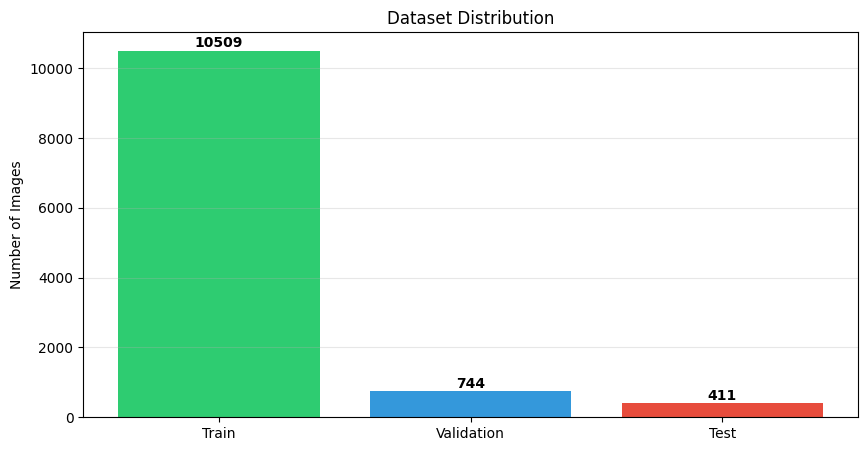

In [4]:
# Count images in each split
train_images = len(list(Path(dataset_path, 'train', 'images').glob('*')))
val_images = len(list(Path(dataset_path, 'valid', 'images').glob('*')))
test_images = len(list(Path(dataset_path, 'test', 'images').glob('*')))

print(f"Training images: {train_images}")
print(f"Validation images: {val_images}")
print(f"Test images: {test_images}")
print(f"Total images: {train_images + val_images + test_images}")

# Visualize dataset distribution
plt.figure(figsize=(10, 5))
splits = ['Train', 'Validation', 'Test']
counts = [train_images, val_images, test_images]
plt.bar(splits, counts, color=['#2ecc71', '#3498db', '#e74c3c'])
plt.ylabel('Number of Images')
plt.title('Dataset Distribution')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.show()

## 5. Display Sample Images

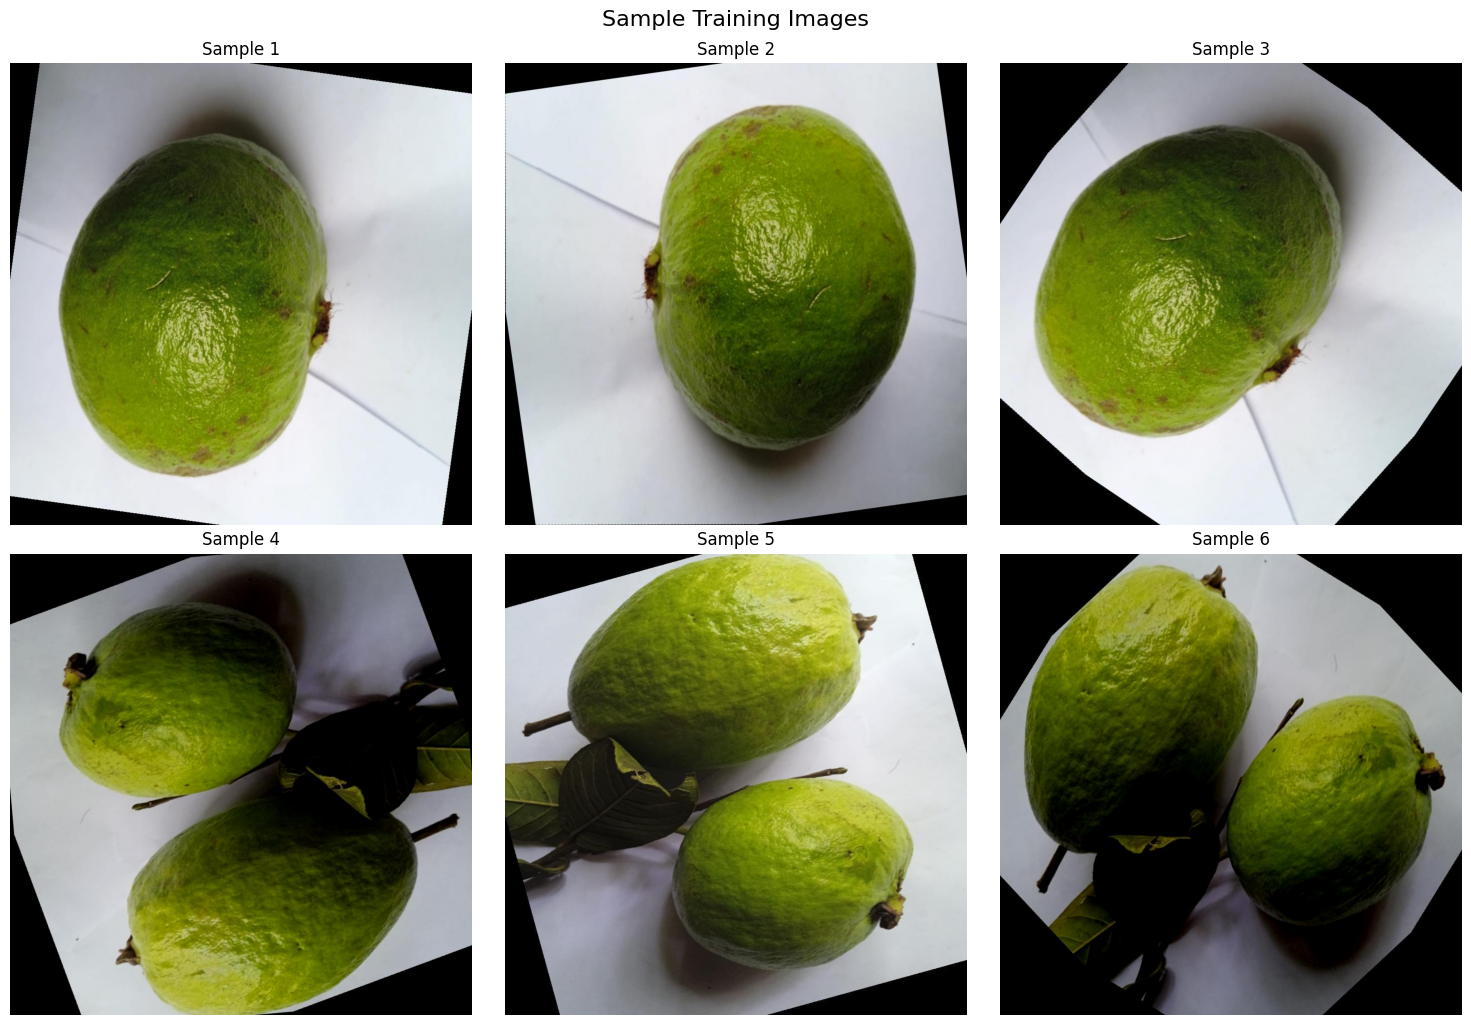

In [5]:
# Display sample images from training set
train_img_path = Path(dataset_path, 'train', 'images')
sample_images = list(train_img_path.glob('*'))[:6]  # Get first 6 images

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(f'Sample {idx+1}')
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Sample Training Images', y=1.02, fontsize=16)
plt.show()

## 6. Initialize YOLOv8 Model

In [6]:
# Load a pre-trained YOLOv8 model (nano version for faster training)
# You can use: yolov8n.pt (nano), yolov8s.pt (small), yolov8m.pt (medium), yolov8l.pt (large), yolov8x.pt (extra large)
model = YOLO('yolov8n.pt')  # Using nano for quick training

print("YOLOv8 model loaded successfully!")
print(f"Model type: YOLOv8 Nano")

YOLOv8 model loaded successfully!
Model type: YOLOv8 Nano


## 7. Train the Model with Real-Time Progress

In [7]:
# Training configuration optimized for CPU-only training
EPOCHS = 50  # As requested
IMG_SIZE = 480  # Smaller size to reduce memory usage
BATCH_SIZE = 8  # Minimum batch size for stability

print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)
print(f"📊 Dataset: {train_images} train, {val_images} val, {test_images} test")
print(f"🎯 Classes: {data_config['nc']} ({', '.join(data_config['names'])})")
print(f"⚙️  Configuration: {EPOCHS} epochs, {IMG_SIZE}x{IMG_SIZE}, batch={BATCH_SIZE}")
print("="*70)
print("\n⏳ Training will display progress for each epoch...\n")

# Force CPU-only mode and hide GPU before importing torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import torch
device = 'cpu'
print("💻 Using CPU-only training (GPU disabled)")
print("   This avoids CUDA memory errors, but will be slower.")

print("\n🔧 CPU-only settings:")
print("   - Device: CPU")
print(f"   - Image size: {IMG_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")
print("   - Workers: 0 (main process only)")
print("   - Cache: Disabled")
print("-"*70)

# Train the model with CPU-only settings
results = model.train(
    data=data_yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=15,
    save=True,
    device='cpu',
    project='runs/detect',
    name='fruit_quality_detection',
    exist_ok=True,
    pretrained=True,
    optimizer='SGD',
    verbose=True,
    seed=42,
    deterministic=False,
    plots=True,
    save_period=10,
    workers=0,
    amp=False,
    cache=False,
    close_mosaic=5
 )

print("\n" + "="*70)
print("✅ TRAINING COMPLETED SUCCESSFULLY!")
print("="*70)


🚀 STARTING TRAINING
📊 Dataset: 10509 train, 744 val, 411 test
🎯 Classes: 5 (FreshGuava, FreshOrange, RottenApple, RottenGuava, RottenOrange)
⚙️  Configuration: 50 epochs, 480x480, batch=8

⏳ Training will display progress for each epoch...

💻 Using CPU-only training (GPU disabled)
   This avoids CUDA memory errors, but will be slower.

🔧 CPU-only settings:
   - Device: CPU
   - Image size: 480
   - Batch size: 8
   - Workers: 0 (main process only)
   - Cache: Disabled
----------------------------------------------------------------------
Ultralytics 8.4.17  Python-3.13.5 torch-2.7.1+cu118 CPU (Intel Core i7-14700HX)
engine\trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Raghuram S\Amrita\4th Sem\Robotics\Project\Dataset\data.yaml, degrees=0.0, determin

KeyboardInterrupt: 

## 8. Epoch-by-Epoch Training Analysis

In [ ]:
# Load and display epoch-by-epoch metrics from CSV results
import pandas as pd

results_dir = Path('runs/detect/fruit_quality_detection')
results_csv = results_dir / 'results.csv'

if results_csv.exists():
    # Read training results
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # Remove any whitespace from column names
    
    print("\n" + "="*100)
    print("📊 EPOCH-BY-EPOCH TRAINING METRICS")
    print("="*100)
    
    # Display last 10 epochs
    print("\n📋 Last 10 Epochs Performance:")
    print("-"*100)
    
    # Select key columns to display
    display_cols = ['epoch']
    for col in df.columns:
        if any(x in col.lower() for x in ['loss', 'precision', 'recall', 'map']):
            display_cols.append(col)
    
    # Show last 10 epochs
    if len(df) > 10:
        print(df[display_cols].tail(10).to_string(index=False))
    else:
        print(df[display_cols].to_string(index=False))
    
    print("\n" + "="*100)
    
    # Plot training progression
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Training & Validation Loss
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', linewidth=2)
    axes[0, 0].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', linewidth=2)
    if 'val/box_loss' in df.columns:
        axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', linewidth=2, linestyle='--')
        axes[0, 0].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', linewidth=2, linestyle='--')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('📉 Training & Validation Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Precision & Recall
    if 'metrics/precision(B)' in df.columns:
        axes[0, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2, color='green')
        axes[0, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2, color='blue')
        axes[0, 1].set_xlabel('Epoch', fontsize=12)
        axes[0, 1].set_ylabel('Score', fontsize=12)
        axes[0, 1].set_title('📈 Precision & Recall Over Epochs', fontsize=14, fontweight='bold')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: mAP Scores
    if 'metrics/mAP50(B)' in df.columns:
        axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', linewidth=2, color='orange')
        axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', linewidth=2, color='red')
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('mAP', fontsize=12)
        axes[1, 0].set_title('🎯 mAP Scores Over Epochs', fontsize=14, fontweight='bold')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Learning Rate
    if 'lr/pg0' in df.columns:
        axes[1, 1].plot(df['epoch'], df['lr/pg0'], linewidth=2, color='purple')
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
        axes[1, 1].set_title('⚙️ Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n📊 TRAINING SUMMARY STATISTICS:")
    print("="*100)
    if 'metrics/mAP50(B)' in df.columns:
        best_epoch = df['metrics/mAP50(B)'].idxmax()
        print(f"🏆 Best Epoch: {int(df.loc[best_epoch, 'epoch'])}")
        print(f"   - mAP50: {df.loc[best_epoch, 'metrics/mAP50(B)']:.4f}")
        print(f"   - mAP50-95: {df.loc[best_epoch, 'metrics/mAP50-95(B)']:.4f}")
        print(f"   - Precision: {df.loc[best_epoch, 'metrics/precision(B)']:.4f}")
        print(f"   - Recall: {df.loc[best_epoch, 'metrics/recall(B)']:.4f}")
    print("="*100)
else:
    print("❌ Results CSV not found. Make sure training completed successfully.")

## 9. Complete Training Metrics Overview

In [ ]:
# Display comprehensive training results
results_dir = Path('runs/detect/fruit_quality_detection')

# Load and display the main results plot (contains loss and metrics over epochs)
results_img = results_dir / 'results.png'
if results_img.exists():
    fig = plt.figure(figsize=(20, 12))
    img = Image.open(results_img)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Training Metrics: Loss, Precision, Recall, mAP over Epochs', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("TRAINING METRICS EXPLANATION:")
    print("="*70)
    print("📊 Box Loss (train/val): Bounding box regression loss - Lower is better")
    print("📊 Class Loss (train/val): Classification loss - Lower is better")
    print("📊 DFL Loss (train/val): Distribution Focal Loss - Lower is better")
    print("📈 Precision: How many detections were correct - Higher is better")
    print("📈 Recall: How many ground truth objects were detected - Higher is better")
    print("📈 mAP50: Mean Average Precision at 0.5 IoU - Higher is better")
    print("📈 mAP50-95: Mean Average Precision at 0.5-0.95 IoU - Higher is better")
    print("="*70)
else:
    print("Results plot not found. Training may not be complete.")

## 10. Confusion Matrix & Performance Curves

In [ ]:
# Display confusion matrix and performance curves
perf_images = [
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized)'),
    ('F1_curve.png', 'F1-Score Curve'),
    ('PR_curve.png', 'Precision-Recall Curve'),
    ('P_curve.png', 'Precision Curve')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for idx, (img_name, title) in enumerate(perf_images):
    img_path = results_dir / img_name
    if img_path.exists():
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(title, fontsize=14, fontweight='bold')
        axes[idx].axis('off')
    else:
        # Try alternative names
        alt_name = img_name.replace('_normalized', '')
        alt_path = results_dir / alt_name
        if alt_path.exists():
            img = Image.open(alt_path)
            axes[idx].imshow(img)
            axes[idx].set_title(title.replace(' (Normalized)', ''), fontsize=14, fontweight='bold')
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f'{img_name} not found', 
                          ha='center', va='center', fontsize=12)
            axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PERFORMANCE ANALYSIS:")
print("="*70)
print("🔍 Confusion Matrix: Shows how well the model classifies each fruit type")
print("   - Diagonal = Correct predictions")
print("   - Off-diagonal = Misclassifications")
print("\n📈 F1 Curve: Balance between Precision and Recall")
print("   - Best F1 score indicates optimal confidence threshold")
print("\n📈 PR Curve: Precision vs Recall trade-off")
print("   - Area under curve indicates overall performance")
print("="*70)

## 11. Validate the Model & Per-Class Metrics

In [ ]:
# Load the best trained model
best_model_path = results_dir / 'weights' / 'best.pt'
model_best = YOLO(best_model_path)

# Validate on test set
validation_results = model_best.val(
    data=data_yaml_path,
    split='test',
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    plots=True
)

print("\n" + "="*70)
print("📊 OVERALL VALIDATION METRICS (Test Set)")
print("="*70)
print(f"✓ mAP50:        {validation_results.box.map50:.4f}  (at IoU=0.50)")
print(f"✓ mAP50-95:     {validation_results.box.map:.4f}  (at IoU=0.50-0.95)")
print(f"✓ Precision:    {validation_results.box.mp:.4f}  (of all predictions)")
print(f"✓ Recall:       {validation_results.box.mr:.4f}  (of all ground truths)")
print("="*70)

    print("Check the confusion matrix for detailed per-class performance.")

# Display per-class metrics    print("Per-class metrics not available in this format.")

print("\n" + "="*70)else:

print("📊 PER-CLASS PERFORMANCE METRICS")    print("="*70)

print("="*70)            print(f"{class_name:<20} {'N/A':<12} {'N/A':<12} {'N/A':<12} {'N/A':<12}")

class_names = data_config['names']        except:

            print(f"{class_name:<20} {prec:<12.4f} {rec:<12.4f} {map50:<12.4f} {map50_95:<12.4f}")

if hasattr(validation_results.box, 'maps'):            

    print(f"\n{'Class':<20} {'Precision':<12} {'Recall':<12} {'mAP50':<12} {'mAP50-95':<12}")            map50_95 = validation_results.box.map_class[idx] if hasattr(validation_results.box, 'map_class') and len(validation_results.box.map_class) > idx else 0

    print("-" * 70)            map50 = validation_results.box.maps[idx] if len(validation_results.box.maps) > idx else 0

                rec = validation_results.box.r[idx] if hasattr(validation_results.box, 'r') else 0

    for idx, class_name in enumerate(class_names):            prec = validation_results.box.p[idx] if hasattr(validation_results.box, 'p') else 0
        try:

## 12. Test Predictions on Sample Images

In [ ]:
# Get sample test images
test_img_path = Path(dataset_path, 'test', 'images')
test_samples = list(test_img_path.glob('*'))[:6]

# Run predictions
predictions = model_best.predict(
    source=test_samples,
    imgsz=IMG_SIZE,
    conf=0.25,  # Confidence threshold
    save=False,
    show_labels=True,
    show_conf=True
)

# Display predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (pred, img_path) in enumerate(zip(predictions, test_samples)):
    # Get the plotted image with predictions
    img_with_pred = pred.plot()
    # Convert BGR to RGB
    img_with_pred = cv2.cvtColor(img_with_pred, cv2.COLOR_BGR2RGB)
    
    axes[idx].imshow(img_with_pred)
    axes[idx].set_title(f'Prediction {idx+1}')
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Test Predictions', y=1.00, fontsize=16, fontweight='bold')
plt.show()

print("\nPredictions completed!")

## 13. Save the Model

In [ ]:
# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Copy best weights to models directory
import shutil

final_model_path = models_dir / 'fruit_detection_best.pt'
shutil.copy(best_model_path, final_model_path)

print(f"Model saved successfully!")
print(f"\nModel locations:")
print(f"  Training weights: {best_model_path}")
print(f"  Final model: {final_model_path}")
print(f"\nModel size: {final_model_path.stat().st_size / (1024*1024):.2f} MB")

## 14. Export Model (Optional)

In [ ]:
# Export to different formats for deployment
# Uncomment the format you need:

# ONNX format (for deployment on various platforms)
# onnx_path = model_best.export(format='onnx')
# print(f"ONNX model saved: {onnx_path}")

# TensorRT (for NVIDIA GPUs)
# trt_path = model_best.export(format='engine')
# print(f"TensorRT model saved: {trt_path}")

# CoreML (for iOS/macOS)
# coreml_path = model_best.export(format='coreml')
# print(f"CoreML model saved: {coreml_path}")

# TFLite (for mobile/edge devices)
# tflite_path = model_best.export(format='tflite')
# print(f"TFLite model saved: {tflite_path}")

print("Export options available. Uncomment the format you need above.")

## 15. Model Summary

In [ ]:
# Print model information
model_info = model_best.model.info()

print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Model: YOLOv8 Nano")
print(f"Classes: {data_config['names']}")
print(f"Number of classes: {data_config['nc']}")
print(f"Training epochs: {EPOCHS}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"\nPerformance Metrics:")
print(f"  mAP50: {validation_results.box.map50:.4f}")
print(f"  mAP50-95: {validation_results.box.map:.4f}")
print(f"  Precision: {validation_results.box.mp:.4f}")
print(f"  Recall: {validation_results.box.mr:.4f}")
print(f"\nModel saved at: {final_model_path}")
print("="*50)

## 16. How to Use the Trained Model

In [ ]:
# Example: Load and use the saved model
print("To use the trained model in your project:\n")
print("```python")
print("from ultralytics import YOLO")
print("")
print("# Load the model")
print("model = YOLO('models/fruit_detection_best.pt')")
print("")
print("# Run inference on an image")
print("results = model('path/to/image.jpg')")
print("")
print("# Process results")
print("for result in results:")
print("    boxes = result.boxes  # Bounding boxes")
print("    probs = result.probs  # Class probabilities")
print("    result.show()  # Display results")
print("```")
print("\nTraining complete! Your model is ready to use.")